# Differential Privacy ML Models Performance Analysis

This notebook visualizes the performance comparison between Differential Privacy (DP) and Standard ML models.


## Cell 1: Import Libraries


In [43]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

## Cell 2: Configuration & Shared Parameters


In [44]:
# ============================================================================
# COLOR PALETTE - Consistent across both graphs
# ============================================================================
color_palette = {
    'dp_lr': '#4292C6',   # DP Logistic Regression - Medium steel blue
    'dp_rf': '#9ECAE1',   # DP Random Forest - Light sky blue
    'std_lr': '#3784FF',  # Standard Logistic Regression - Deep navy blue
    'std_rf': '#226DB8'   # Standard Random Forest - Royal blue
}

# ============================================================================
# CUSTOMIZABLE PARAMETERS
# ============================================================================
# Graph 1 Parameters
EPSILON_INDEX = 5          # Index for epsilon value (5 = ε=1.0 in the 15-value list)
FIGURE_SIZE_1 = (11, 6.5)  # Figure dimensions for Graph 1
BAR_WIDTH = 0.18           # Width of each bar
GROUP_GAP = 0.35           # Gap between metric groups
SHOW_VALUES = True         # Show values on top of bars
VALUE_FONTSIZE = 9         # Font size for values on bars

# Graph 2 Parameters
FIGURE_SIZE_2 = (12, 7)    # Figure dimensions for Graph 2
LINE_WIDTH = 2.5           # Width of plot lines
MARKER_SIZE = 8            # Size of markers

# Shared Parameters
DPI = 300                  # Resolution for saved images
GRID_ALPHA = 0.25          # Grid transparency

## Cell 3: Shared Data


In [45]:
import json
import os
import numpy as np

# ============================================================================
# LOAD DATA FROM JSON FILES
# ============================================================================
_nb_dir = os.path.dirname(os.path.abspath("combined_graphs.ipynb"))

with open(os.path.join(_nb_dir, "../LR/data/std_lr_report.json")) as f:
    _std_lr_raw = json.load(f)

with open(os.path.join(_nb_dir, "../RandomForest/std_rf_report.json")) as f:
    _std_rf_raw = json.load(f)

with open(os.path.join(_nb_dir, "../LR/data/dp_lr_report.json")) as f:
    _dp_lr_raw = json.load(f)

with open(os.path.join(_nb_dir, "../RandomForest/dp_rf_report.json")) as f:
    _dp_rf_raw = json.load(f)

# ============================================================================
# STANDARD LR  (macro-avg from classification_report)
# ============================================================================
_std_lr_cr = _std_lr_raw["classification_report"]
_std_lr = {
    "accuracy":  _std_lr_raw["accuracy"],
    "precision": _std_lr_cr["macro avg"]["precision"],
    "recall":    _std_lr_cr["macro avg"]["recall"],
    "f1_score":  _std_lr_cr["macro avg"]["f1-score"],
}

# ============================================================================
# STANDARD RF  (compute macro-avg from confusion matrix)
# confusion_matrix = [[TN_benign, FP_malignant], [FN_malignant, TP_malignant]]
# ============================================================================
_cm = _std_rf_raw["confusion_matrix"]
_tn, _fp = _cm[0][0], _cm[0][1]
_fn, _tp = _cm[1][0], _cm[1][1]

_b_prec = _tn / (_tn + _fn)
_b_rec  = _tn / (_tn + _fp)
_b_f1   = 2 * _b_prec * _b_rec / (_b_prec + _b_rec)
_m_prec = _tp / (_tp + _fp)
_m_rec  = _tp / (_tp + _fn)
_m_f1   = 2 * _m_prec * _m_rec / (_m_prec + _m_rec)

_std_rf = {
    "accuracy":  _std_rf_raw["accuracy"],
    "precision": (_b_prec + _m_prec) / 2,
    "recall":    (_b_rec  + _m_rec)  / 2,
    "f1_score":  (_b_f1   + _m_f1)   / 2,
}

# ============================================================================
# HELPER: build per-epsilon arrays (mean, std, 95% CI half-width)
# ============================================================================
def _extract(eps_results, mean_key, std_key, n_runs=30):
    means = [eps_results[k][mean_key] for k in eps_results]
    stds  = [eps_results[k][std_key]  for k in eps_results]
    ci95  = [1.96 * s / np.sqrt(n_runs) for s in stds]
    return means, stds, ci95

# ============================================================================
# DP LR
# ============================================================================
_dp_lr_eps  = _dp_lr_raw["epsilon_results"]
_n_lr       = _dp_lr_raw["n_runs_per_epsilon"]
_dp_lr_epsilons = [float(k) for k in _dp_lr_eps.keys()]

_acc_mean,  _acc_std,  _acc_ci  = _extract(_dp_lr_eps, "accuracy_mean",  "accuracy_std",  _n_lr)
_prec_mean, _prec_std, _prec_ci = _extract(_dp_lr_eps, "precision_mean", "precision_std", _n_lr)
_rec_mean,  _rec_std,  _rec_ci  = _extract(_dp_lr_eps, "recall_mean",    "recall_std",    _n_lr)
_f1_mean,   _f1_std,   _f1_ci   = _extract(_dp_lr_eps, "f1_mean",        "f1_std",        _n_lr)

_dp_lr = {
    "epsilon_values": _dp_lr_epsilons,
    "n_runs": _n_lr,
    "accuracy":       _acc_mean,  "accuracy_std":   _acc_std,  "accuracy_ci95":   _acc_ci,
    "precision":      _prec_mean, "precision_std":  _prec_std, "precision_ci95":  _prec_ci,
    "recall":         _rec_mean,  "recall_std":     _rec_std,  "recall_ci95":     _rec_ci,
    "f1_score":       _f1_mean,   "f1_std":         _f1_std,   "f1_ci95":         _f1_ci,
}

# ============================================================================
# DP RF
# ============================================================================
_dp_rf_eps  = _dp_rf_raw["epsilon_results"]
_n_rf       = _dp_rf_raw["n_runs_per_epsilon"]
_dp_rf_epsilons = [float(k) for k in _dp_rf_eps.keys()]

_acc_mean,  _acc_std,  _acc_ci  = _extract(_dp_rf_eps, "accuracy_mean",  "accuracy_std",  _n_rf)
_prec_mean, _prec_std, _prec_ci = _extract(_dp_rf_eps, "precision_mean", "precision_std", _n_rf)
_rec_mean,  _rec_std,  _rec_ci  = _extract(_dp_rf_eps, "recall_mean",    "recall_std",    _n_rf)
_f1_mean,   _f1_std,   _f1_ci   = _extract(_dp_rf_eps, "f1_mean",        "f1_std",        _n_rf)

_dp_rf = {
    "epsilon_values": _dp_rf_epsilons,
    "n_runs": _n_rf,
    "accuracy":       _acc_mean,  "accuracy_std":   _acc_std,  "accuracy_ci95":   _acc_ci,
    "precision":      _prec_mean, "precision_std":  _prec_std, "precision_ci95":  _prec_ci,
    "recall":         _rec_mean,  "recall_std":     _rec_std,  "recall_ci95":     _rec_ci,
    "f1_score":       _f1_mean,   "f1_std":         _f1_std,   "f1_ci95":         _f1_ci,
}

# ============================================================================
# SHARED DATA DICT
# ============================================================================
data = {
    "dp_lr":  _dp_lr,
    "std_lr": _std_lr,
    "std_rf": _std_rf,
    "dp_rf":  _dp_rf,
}

print("Data loaded successfully.")
print(f"  STD-LR  acc={data['std_lr']['accuracy']:.4f}  prec={data['std_lr']['precision']:.4f}  rec={data['std_lr']['recall']:.4f}  f1={data['std_lr']['f1_score']:.4f}")
print(f"  STD-RF  acc={data['std_rf']['accuracy']:.4f}  prec={data['std_rf']['precision']:.4f}  rec={data['std_rf']['recall']:.4f}  f1={data['std_rf']['f1_score']:.4f}")
print(f"  DP-LR   {len(data['dp_lr']['epsilon_values'])} epsilon values, {_n_lr} runs each")
print(f"  DP-RF   {len(data['dp_rf']['epsilon_values'])} epsilon values, {_n_rf} runs each")

Data loaded successfully.
  STD-LR  acc=0.9649  prec=0.9672  rec=0.9573  f1=0.9619
  STD-RF  acc=0.9675  prec=0.9737  rec=0.9524  f1=0.9615
  DP-LR   15 epsilon values, 30 runs each
  DP-RF   15 epsilon values, 30 runs each


## Cell 4: Helper Function - Apply Shared Styling


In [46]:
def apply_shared_styling(ax, fig):
    """Apply consistent styling to both graphs"""
    plt.style.use('seaborn-v0_8-darkgrid')
    ax.set_facecolor('#f8f9fa')
    fig.patch.set_facecolor('white')
    
    # Enhanced grid
    ax.grid(axis='y', alpha=GRID_ALPHA, linestyle='-', linewidth=0.8, color='#7f8c8d', zorder=0)
    ax.grid(axis='y', which='minor', alpha=0.12, linestyle=':', linewidth=0.5, color='#95a5a6', zorder=0)
    ax.set_axisbelow(True)
    
    # Tick parameters
    ax.tick_params(axis='both', which='major', labelsize=11, length=6, width=1.2, colors='#2c3e50')
    ax.tick_params(axis='both', which='minor', length=3, width=0.8, colors='#7f8c8d')
    
    # Border styling
    for spine in ax.spines.values():
        spine.set_edgecolor('#34495e')
        spine.set_linewidth(1.5)

def create_legend(ax, loc='upper left', ncol=1):
    """Create consistently styled legend"""
    legend = ax.legend(loc=loc, 
                       fontsize=10, 
                       frameon=True, 
                       edgecolor='#34495e',
                       fancybox=True,
                       shadow=True,
                       ncol=ncol,
                       framealpha=0.95,
                       borderpad=0.6,
                       labelspacing=0.5,
                       columnspacing=1.0,
                       handlelength=1.5,
                       handletextpad=0.5)
    legend.get_frame().set_facecolor('#ecf0f1')
    return legend

## Cell 5: Graph 1 - Performance Comparison Bar Chart


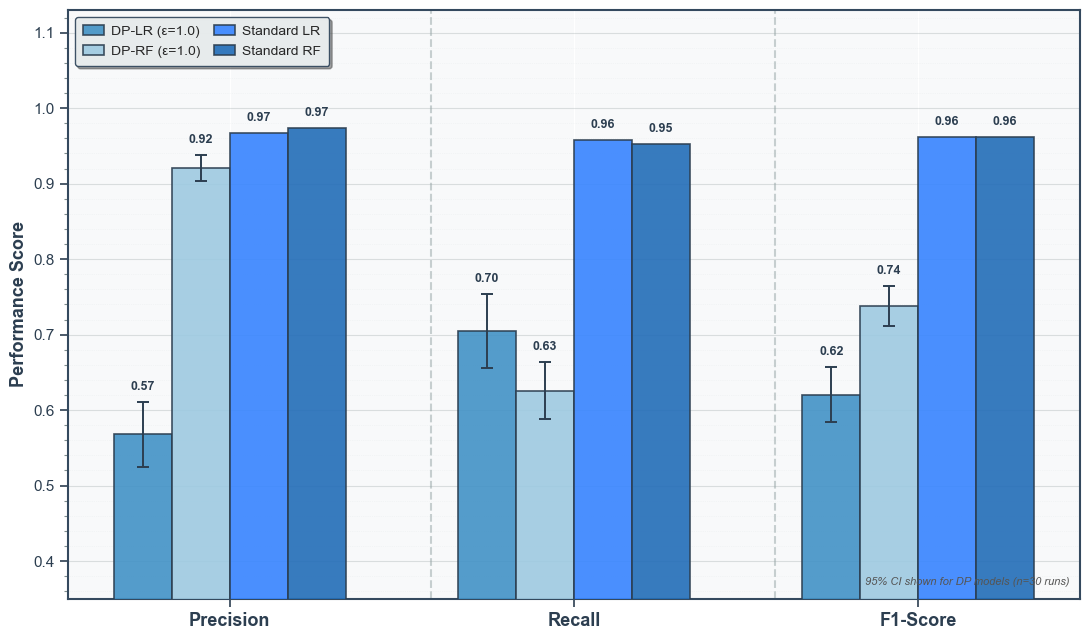

✓ Graph 1: Performance comparison generated!

Selected Privacy Budget: ε = 1.0
DP-LR  precision=0.5678 ± 0.0427 (95% CI)
DP-RF  precision=0.9208 ± 0.0172 (95% CI)


In [47]:
# Get epsilon value for selected index
epsilon_value = data['dp_lr']['epsilon_values'][EPSILON_INDEX]

# Create figure
fig, ax = plt.subplots(figsize=FIGURE_SIZE_1)
apply_shared_styling(ax, fig)

# Prepare data - 4 models
models = [
    f'DP-LR\n(ε={epsilon_value})', 
    f'DP-RF\n(ε={epsilon_value})', 
    'Standard\nLR', 
    'Standard\nRF'
]

colors = [
    color_palette['dp_lr'],
    color_palette['dp_rf'],
    color_palette['std_lr'],
    color_palette['std_rf']
]

# Mean values
precision_values = [
    data['dp_lr']['precision'][EPSILON_INDEX],
    data['dp_rf']['precision'][EPSILON_INDEX],
    data['std_lr']['precision'],
    data['std_rf']['precision']
]

recall_values = [
    data['dp_lr']['recall'][EPSILON_INDEX],
    data['dp_rf']['recall'][EPSILON_INDEX],
    data['std_lr']['recall'],
    data['std_rf']['recall']
]

f1_values = [
    data['dp_lr']['f1_score'][EPSILON_INDEX],
    data['dp_rf']['f1_score'][EPSILON_INDEX],
    data['std_lr']['f1_score'],
    data['std_rf']['f1_score']
]

# 95% CI half-widths (None for standard models — single deterministic run)
precision_ci = [data['dp_lr']['precision_ci95'][EPSILON_INDEX], data['dp_rf']['precision_ci95'][EPSILON_INDEX], None, None]
recall_ci    = [data['dp_lr']['recall_ci95'][EPSILON_INDEX],    data['dp_rf']['recall_ci95'][EPSILON_INDEX],    None, None]
f1_ci        = [data['dp_lr']['f1_ci95'][EPSILON_INDEX],        data['dp_rf']['f1_ci95'][EPSILON_INDEX],        None, None]

# Set up bar positions
n_metrics = 3
n_models  = 4
metric_names = ['Precision', 'Recall', 'F1-Score']
x_base = np.arange(n_metrics) * (n_models * BAR_WIDTH + GROUP_GAP)

errorbar_kw = dict(elinewidth=1.4, ecolor='#2c3e50', capsize=4, capthick=1.4, zorder=4)

for i, model_name in enumerate(models):
    metric_values = [precision_values[i], recall_values[i], f1_values[i]]
    metric_ci     = [precision_ci[i],     recall_ci[i],     f1_ci[i]]
    x_positions   = x_base + i * BAR_WIDTH

    bars = ax.bar(x_positions, metric_values, BAR_WIDTH, 
                   label=model_name.replace('\n', ' '), 
                   color=colors[i], 
                   edgecolor='#2c3e50', 
                   linewidth=1.2, 
                   alpha=0.9,
                   zorder=3)

    # Error bars for DP models
    if metric_ci[0] is not None:
        ax.errorbar(x_positions, metric_values, yerr=metric_ci,
                    fmt='none', **errorbar_kw)

    # Value labels on bars
    if SHOW_VALUES:
        for bar, ci in zip(bars, metric_ci):
            height = bar.get_height()
            offset = (ci if ci is not None else 0) + 0.012
            ax.text(bar.get_x() + bar.get_width()/2., height + offset,
                    f'{height:.2f}',
                    ha='center', va='bottom', 
                    fontsize=VALUE_FONTSIZE, 
                    fontweight='bold',
                    color='#2c3e50')

# x-axis labels
x_center = x_base + (n_models * BAR_WIDTH) / 2 - BAR_WIDTH / 2
ax.set_xticks(x_center)
ax.set_xticklabels(metric_names, fontsize=13, fontweight='bold')

ax.set_ylabel('Performance Score', fontsize=13, fontweight='bold', color='#2c3e50')
ax.set_ylim(0.35, 1.13)
ax.yaxis.set_minor_locator(MultipleLocator(0.02))

# Annotate CI note
ax.text(0.99, 0.02, '95% CI shown for DP models (n=30 runs)',
        transform=ax.transAxes, fontsize=8, color='#555555',
        ha='right', va='bottom', style='italic')

create_legend(ax, loc='upper left', ncol=2)

for i in range(1, n_metrics):
    separator_x = x_base[i] - GROUP_GAP / 2
    ax.axvline(x=separator_x, color='#95a5a6', linestyle='--', 
               linewidth=1.5, alpha=0.5, zorder=2)

plt.tight_layout()
plt.show()

print("✓ Graph 1: Performance comparison generated!\n")
print("="*70)
print(f"Selected Privacy Budget: ε = {epsilon_value}")
print(f"DP-LR  precision={data['dp_lr']['precision'][EPSILON_INDEX]:.4f} ± {data['dp_lr']['precision_ci95'][EPSILON_INDEX]:.4f} (95% CI)")
print(f"DP-RF  precision={data['dp_rf']['precision'][EPSILON_INDEX]:.4f} ± {data['dp_rf']['precision_ci95'][EPSILON_INDEX]:.4f} (95% CI)")
print("="*70)

## Cell 6: Graph 2 - Epsilon vs Accuracy Line Chart


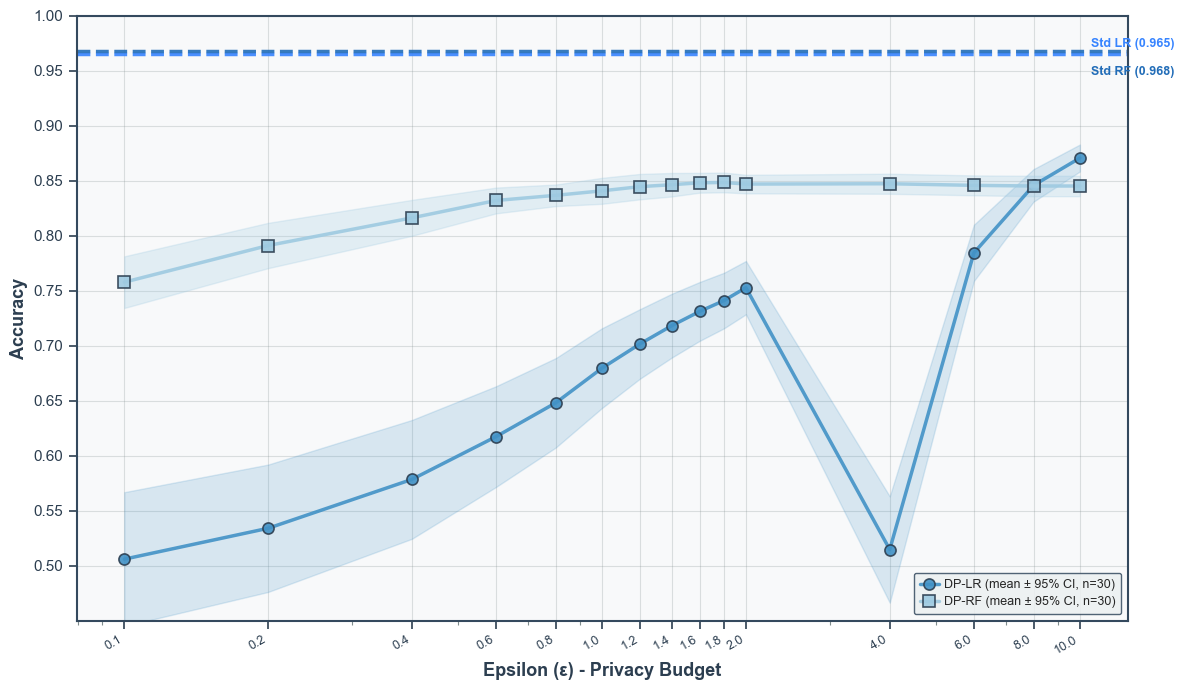

✓ Graph 2: Epsilon vs Accuracy (with 95% CI bands) generated!

KEY INSIGHTS:
- Standard Random Forest: 96.75%
- Standard Logistic Regression: 96.49%
- DP-LR at ε=1.0: 67.95% ± 3.62% (95% CI)
- DP-RF at ε=1.0: 84.06% ± 1.18% (95% CI)
- DP-LR at ε=10.0: 87.05% ± 1.23% (95% CI)
- DP-RF at ε=10.0: 84.50% ± 0.93% (95% CI)


In [51]:
_eps_lr = np.array(data['dp_lr']['epsilon_values'])
_eps_rf = np.array(data['dp_rf']['epsilon_values'])
_acc_lr = np.array(data['dp_lr']['accuracy'])
_acc_rf = np.array(data['dp_rf']['accuracy'])
_ci_lr  = np.array(data['dp_lr']['accuracy_ci95'])
_ci_rf  = np.array(data['dp_rf']['accuracy_ci95'])

# Create figure
fig, ax = plt.subplots(figsize=FIGURE_SIZE_2)
apply_shared_styling(ax, fig)

# ---- DP LR: shaded CI band + mean line ----
ax.fill_between(_eps_lr, _acc_lr - _ci_lr, _acc_lr + _ci_lr,
                color=color_palette['dp_lr'], alpha=0.18, zorder=2,
                label='_nolegend_')
ax.plot(_eps_lr, _acc_lr,
        marker='o', linewidth=LINE_WIDTH, markersize=MARKER_SIZE,
        color=color_palette['dp_lr'],
        label=f'DP-LR (mean ± 95% CI, n={data["dp_lr"]["n_runs"]})',
        linestyle='-', alpha=0.9,
        markeredgecolor='#2c3e50', markeredgewidth=1.2, zorder=3)

# ---- DP RF: shaded CI band + mean line ----
ax.fill_between(_eps_rf, _acc_rf - _ci_rf, _acc_rf + _ci_rf,
                color=color_palette['dp_rf'], alpha=0.25, zorder=2,
                label='_nolegend_')
ax.plot(_eps_rf, _acc_rf,
        marker='s', linewidth=LINE_WIDTH, markersize=MARKER_SIZE,
        color=color_palette['dp_rf'],
        label=f'DP-RF (mean ± 95% CI, n={data["dp_rf"]["n_runs"]})',
        linestyle='-', alpha=0.9,
        markeredgecolor='#2c3e50', markeredgewidth=1.2, zorder=3)

# ---- Standard models: dashed horizontal lines (no legend entry) ----
ax.axhline(y=data['std_lr']['accuracy'],
           color=color_palette['std_lr'], linestyle='--', linewidth=LINE_WIDTH,
           alpha=0.9, zorder=2, label='_nolegend_')

ax.axhline(y=data['std_rf']['accuracy'],
           color=color_palette['std_rf'], linestyle='--', linewidth=LINE_WIDTH,
           alpha=0.9, zorder=2, label='_nolegend_')

# ---- Inline annotations for standard baselines (right edge of plot) ----
_std_lr_acc = data['std_lr']['accuracy']
_std_rf_acc = data['std_rf']['accuracy']
_x_annot = _eps_lr[-1] * 1.02   # just past the last epsilon tick

ax.annotate(f'Std LR ({_std_lr_acc:.3f})',
            xy=(_eps_lr[-1], _std_lr_acc),
            xytext=(8, 3), textcoords='offset points',
            fontsize=9, fontweight='bold',
            color=color_palette['std_lr'],
            va='bottom', ha='left',
            arrowprops=None,
            annotation_clip=False)

ax.annotate(f'Std RF ({_std_rf_acc:.3f})',
            xy=(_eps_lr[-1], _std_rf_acc),
            xytext=(8, -10), textcoords='offset points',
            fontsize=9, fontweight='bold',
            color=color_palette['std_rf'],
            va='top', ha='left',
            annotation_clip=False)

# Labels
ax.set_xlabel('Epsilon (ε) - Privacy Budget', fontsize=13, fontweight='bold', color='#2c3e50')
ax.set_ylabel('Accuracy', fontsize=13, fontweight='bold', color='#2c3e50')

ax.set_xscale('log')
ax.grid(True, axis='x', alpha=GRID_ALPHA, linestyle='-', linewidth=0.8, color='#7f8c8d', zorder=0)

# Compact legend — only 2 DP entries, placed upper left away from data
legend = ax.legend(loc='lower right',
                   fontsize=9,
                   frameon=True,
                   edgecolor='#34495e',
                   fancybox=True,
                   shadow=False,
                   ncol=1,
                   framealpha=0.85,
                   borderpad=0.5,
                   labelspacing=0.4,
                   handlelength=1.5,
                   handletextpad=0.4)
legend.get_frame().set_facecolor('#ecf0f1')

ax.set_ylim(0.45, 1.0)
_eps_ticks = data['dp_lr']['epsilon_values']
ax.set_xticks(_eps_ticks)
ax.set_xticklabels([str(x) for x in _eps_ticks], fontsize=9, rotation=30, ha='right')
ax.set_yticks(np.arange(0.50, 1.01, 0.05))

plt.tight_layout()
plt.show()

print("✓ Graph 2: Epsilon vs Accuracy (with 95% CI bands) generated!\n")
print("="*70)
print("KEY INSIGHTS:")
print("="*70)
print(f"- Standard Random Forest: {data['std_rf']['accuracy']:.2%}")
print(f"- Standard Logistic Regression: {data['std_lr']['accuracy']:.2%}")
_idx_lr = data['dp_lr']['epsilon_values'].index(1.0)
_idx_rf = data['dp_rf']['epsilon_values'].index(1.0)
print(f"- DP-LR at ε=1.0: {data['dp_lr']['accuracy'][_idx_lr]:.2%} ± {data['dp_lr']['accuracy_ci95'][_idx_lr]:.2%} (95% CI)")
print(f"- DP-RF at ε=1.0: {data['dp_rf']['accuracy'][_idx_rf]:.2%} ± {data['dp_rf']['accuracy_ci95'][_idx_rf]:.2%} (95% CI)")
print(f"- DP-LR at ε={data['dp_lr']['epsilon_values'][-1]}: {data['dp_lr']['accuracy'][-1]:.2%} ± {data['dp_lr']['accuracy_ci95'][-1]:.2%} (95% CI)")
print(f"- DP-RF at ε={data['dp_rf']['epsilon_values'][-1]}: {data['dp_rf']['accuracy'][-1]:.2%} ± {data['dp_rf']['accuracy_ci95'][-1]:.2%} (95% CI)")
print("="*70)


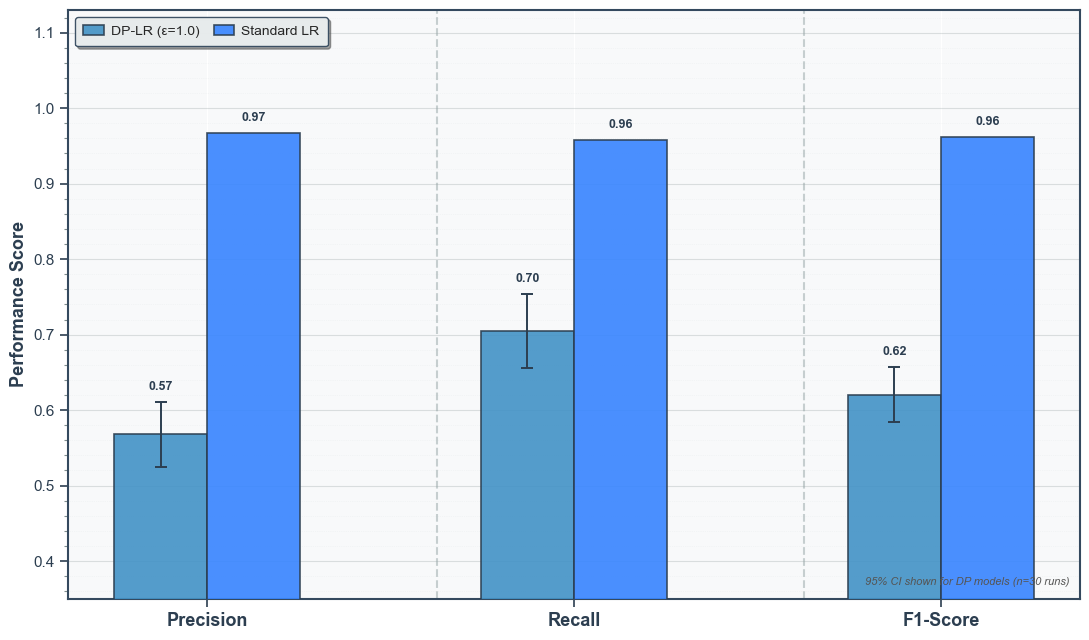

✓ Graph A: Logistic Regression comparison generated!

DP-LR at ε=1.0:
  precision=0.5678 ± 0.0427
  recall   =0.7048 ± 0.0493
  f1       =0.6203 ± 0.0367


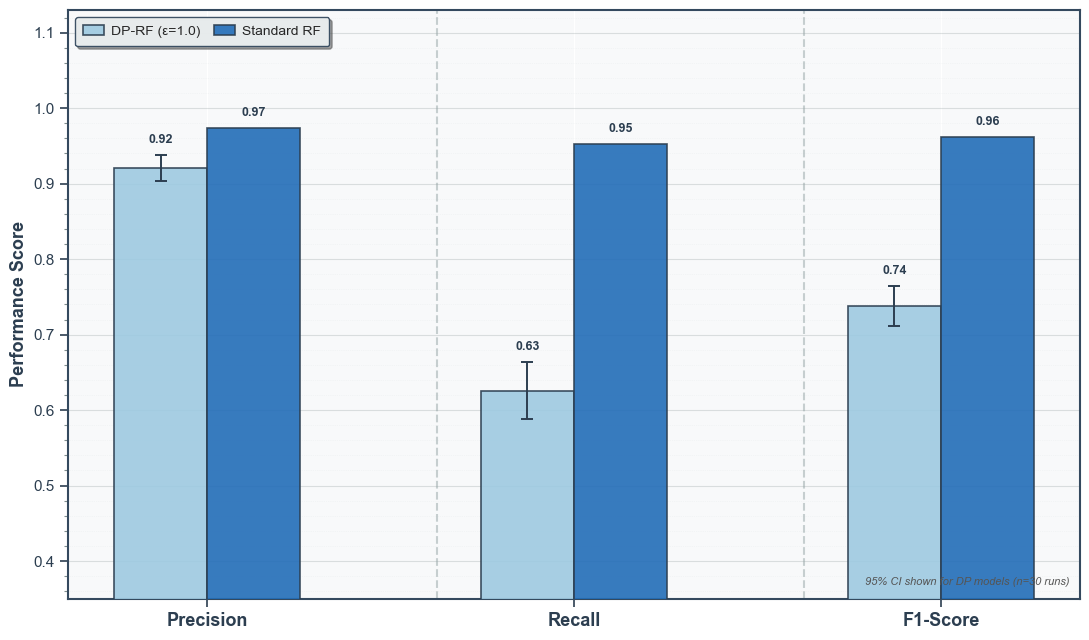


✓ Graph B: Random Forest comparison generated!

DP-RF at ε=1.0:
  precision=0.9208 ± 0.0172
  recall   =0.6254 ± 0.0378
  f1       =0.7380 ± 0.0264


In [ ]:
epsilon_value = data['dp_lr']['epsilon_values'][EPSILON_INDEX]
errorbar_kw   = dict(elinewidth=1.4, ecolor='#2c3e50', capsize=4, capthick=1.4, zorder=4)

def _bar_group(ax, models, colors, metric_rows, ci_rows, metric_names):
    """Draw a grouped bar chart with optional CI error bars."""
    n_metrics = len(metric_names)
    n_models  = len(models)
    x_base = np.arange(n_metrics) * (n_models * BAR_WIDTH + GROUP_GAP)

    for i, model_name in enumerate(models):
        vals = [metric_rows[m][i] for m in range(n_metrics)]
        cis  = [ci_rows[m][i]     for m in range(n_metrics)]
        x_pos = x_base + i * BAR_WIDTH

        bars = ax.bar(x_pos, vals, BAR_WIDTH,
                      label=model_name.replace('\n', ' '),
                      color=colors[i], edgecolor='#2c3e50',
                      linewidth=1.2, alpha=0.9, zorder=3)

        if cis[0] is not None:
            ax.errorbar(x_pos, vals, yerr=cis, fmt='none', **errorbar_kw)

        if SHOW_VALUES:
            for bar, ci in zip(bars, cis):
                height = bar.get_height()
                offset = (ci if ci is not None else 0) + 0.012
                ax.text(bar.get_x() + bar.get_width()/2., height + offset,
                        f'{height:.2f}',
                        ha='center', va='bottom',
                        fontsize=VALUE_FONTSIZE, fontweight='bold', color='#2c3e50')

    x_center = x_base + (n_models * BAR_WIDTH) / 2 - BAR_WIDTH / 2
    ax.set_xticks(x_center)
    ax.set_xticklabels(metric_names, fontsize=13, fontweight='bold')

    for j in range(1, n_metrics):
        ax.axvline(x=x_base[j] - GROUP_GAP / 2,
                   color='#95a5a6', linestyle='--', linewidth=1.5, alpha=0.5, zorder=2)


# ===========================================================================
# GRAPH A: Standard LR vs DP-LR
# ===========================================================================
fig, ax = plt.subplots(figsize=FIGURE_SIZE_1)
apply_shared_styling(ax, fig)

_bar_group(
    ax,
    models   = [f'DP-LR\n(ε={epsilon_value})', 'Standard\nLR'],
    colors   = [color_palette['dp_lr'], color_palette['std_lr']],
    metric_rows = [
        [data['dp_lr']['precision'][EPSILON_INDEX], data['std_lr']['precision']],
        [data['dp_lr']['recall'][EPSILON_INDEX],    data['std_lr']['recall']],
        [data['dp_lr']['f1_score'][EPSILON_INDEX],  data['std_lr']['f1_score']],
    ],
    ci_rows = [
        [data['dp_lr']['precision_ci95'][EPSILON_INDEX], None],
        [data['dp_lr']['recall_ci95'][EPSILON_INDEX],    None],
        [data['dp_lr']['f1_ci95'][EPSILON_INDEX],        None],
    ],
    metric_names = ['Precision', 'Recall', 'F1-Score'],
)

ax.set_ylabel('Performance Score', fontsize=13, fontweight='bold', color='#2c3e50')
ax.set_ylim(0.35, 1.13)
ax.yaxis.set_minor_locator(MultipleLocator(0.02))
ax.text(0.99, 0.02, '95% CI shown for DP models (n=30 runs)',
        transform=ax.transAxes, fontsize=8, color='#555555',
        ha='right', va='bottom', style='italic')
create_legend(ax, loc='upper left', ncol=2)

plt.tight_layout()
plt.show()

print("✓ Graph A: Logistic Regression comparison generated!\n")
print("="*70)
print(f"DP-LR at ε={epsilon_value}:")
print(f"  precision={data['dp_lr']['precision'][EPSILON_INDEX]:.4f} ± {data['dp_lr']['precision_ci95'][EPSILON_INDEX]:.4f}")
print(f"  recall   ={data['dp_lr']['recall'][EPSILON_INDEX]:.4f} ± {data['dp_lr']['recall_ci95'][EPSILON_INDEX]:.4f}")
print(f"  f1       ={data['dp_lr']['f1_score'][EPSILON_INDEX]:.4f} ± {data['dp_lr']['f1_ci95'][EPSILON_INDEX]:.4f}")
print("="*70)


# ===========================================================================
# GRAPH B: Standard RF vs DP-RF
# ===========================================================================
fig, ax = plt.subplots(figsize=FIGURE_SIZE_1)
apply_shared_styling(ax, fig)

_bar_group(
    ax,
    models   = [f'DP-RF\n(ε={epsilon_value})', 'Standard\nRF'],
    colors   = [color_palette['dp_rf'], color_palette['std_rf']],
    metric_rows = [
        [data['dp_rf']['precision'][EPSILON_INDEX], data['std_rf']['precision']],
        [data['dp_rf']['recall'][EPSILON_INDEX],    data['std_rf']['recall']],
        [data['dp_rf']['f1_score'][EPSILON_INDEX],  data['std_rf']['f1_score']],
    ],
    ci_rows = [
        [data['dp_rf']['precision_ci95'][EPSILON_INDEX], None],
        [data['dp_rf']['recall_ci95'][EPSILON_INDEX],    None],
        [data['dp_rf']['f1_ci95'][EPSILON_INDEX],        None],
    ],
    metric_names = ['Precision', 'Recall', 'F1-Score'],
)

ax.set_ylabel('Performance Score', fontsize=13, fontweight='bold', color='#2c3e50')
ax.set_ylim(0.35, 1.13)
ax.yaxis.set_minor_locator(MultipleLocator(0.02))
ax.text(0.99, 0.02, '95% CI shown for DP models (n=30 runs)',
        transform=ax.transAxes, fontsize=8, color='#555555',
        ha='right', va='bottom', style='italic')
create_legend(ax, loc='upper left', ncol=2)

plt.tight_layout()
plt.show()

print("\n✓ Graph B: Random Forest comparison generated!\n")
print("="*70)
print(f"DP-RF at ε={epsilon_value}:")
print(f"  precision={data['dp_rf']['precision'][EPSILON_INDEX]:.4f} ± {data['dp_rf']['precision_ci95'][EPSILON_INDEX]:.4f}")
print(f"  recall   ={data['dp_rf']['recall'][EPSILON_INDEX]:.4f} ± {data['dp_rf']['recall_ci95'][EPSILON_INDEX]:.4f}")
print(f"  f1       ={data['dp_rf']['f1_score'][EPSILON_INDEX]:.4f} ± {data['dp_rf']['f1_ci95'][EPSILON_INDEX]:.4f}")
print("="*70)